## Power Spectral Densities Tutorial

In this tutorial, we will explore (with **kea**) estimation of the power spectral density.

First, import **kea** and generate a field.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
# modify_latex_rc()
# modify_latex_rc()

# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode, set_fitting_mode
set_calculation_mode(use_cpu=False, use_gpu=True)
set_fitting_mode(gaussian_process=True)

from kea.simulator import make_field

# Set number of grid points
N = 1024
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,N)

# Make the field
field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


In [2]:
# KEA is aware of the physical scale. You can change this scale by providing `phys_dims` to most functions
#   or via changing the default physical scale (which is 2pi)
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = 5.*np.pi

### Periodogram (FFT)

The FFT method directly uses the squared magnitude of the fast-Fourier transform of the field. It provides a "modal" spectrum i.e., a spectrum that is dependent on the wave-vector.

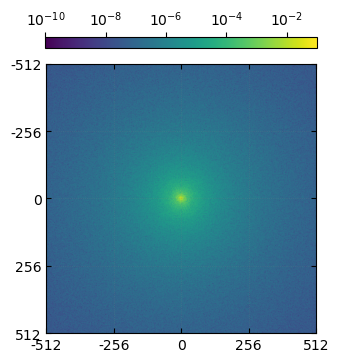

In [3]:
from kea.statistics.spectra import fourier_modal_spectrum
# Directly compute the power spectrum using the fast Fourier transform
kvec, fft_spectrum = fourier_modal_spectrum(field)

## Plot the 2D spectrum
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(fft_spectrum, cmap='viridis', norm=mpl.colors.LogNorm(1e-10, 1e-1))
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

We will bin the FFT spectrum into the "angle-integrated" and "angle-averaged" spectra for comparison with the other methods.

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


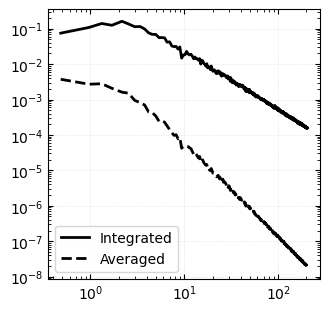

In [4]:
# import the spectrum binning function
from kea.statistics.spectra import bin_spectrum
# Bin to the angle-integrated (integrate over circular shells)
kp_integrated, fek_integrated, p_widths = bin_spectrum(kvec, fft_spectrum, 'integrated')
# Bin to the angle-averaged (average circular shells)
kp_averaged, fek_averaged, _ = bin_spectrum(kvec, fft_spectrum, 'averaged')

## Plot both binned spectra types
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kp_integrated, fek_integrated, linestyle='-', color='black', linewidth=2., label='Integrated')
ax.plot(kp_averaged, fek_averaged, linestyle='--', color='black', linewidth=2., label='Averaged')
pretty_axes(ax)
ax.loglog()
ax.legend()

The above figure shows that the angle-integrated and angle-averaged can be different. This is due to the integration/averaging factor in the circular shell volumes. We can convert between them by assuming isotropy and using the shell volume formula as a pre-factor to convert between them.

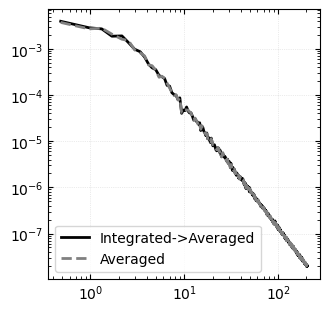

In [5]:
# import helper function to convert
from kea.statistics.spectra import transform_spectrum
# Convert from the integrated spectrum to the averaged spectrum
ki_averaged, feki_averaged = transform_spectrum(kp_integrated, fek_integrated, D, 'integrated', 'averaged', grid_dims, bin_widths=p_widths, is_centered=True)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(ki_averaged, feki_averaged, linestyle='-', color='black', linewidth=2., label='Integrated->Averaged')
ax.plot(kp_averaged, fek_averaged, linestyle='--', color='gray', linewidth=2., label='Averaged')
pretty_axes(ax)
ax.loglog()
ax.legend()

### Correlogram/Blackman-Tukey (BT)

The BT method uses the property that the power spectrum is the Fourier transform of the autocorrelation function. This method also produces a "modal" spectrum.

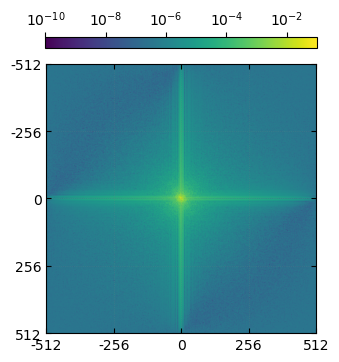

In [6]:
from kea.statistics.statfunc import complete_symmetric_correlation_function
from kea.statistics.spectra import bt_modal_spectrum

# First calculate the ACF
lags, acf_full = complete_symmetric_correlation_function(field)
# Compute the correlogram
kvec_bt, bt_spectrum = bt_modal_spectrum(acf_full)

## Plot the 2D spectrum
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
im = ax.imshow(bt_spectrum, cmap='viridis', norm=mpl.colors.LogNorm(1e-10, 1e-1))
pretty_axes(ax)
ax.set_xticks(*make_ax_step(N, N//4))
ax.set_yticks(*make_ax_step(N, N//4))
cbar_ax = fig.add_axes([0.125, 0.925, 0.775, 0.03])
fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar_ax.xaxis.set_ticks_position('top')

In [7]:
kbt_averaged, fekbt_averaged, _ = bin_spectrum(kvec_bt, bt_spectrum, 'averaged')

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


### Equivalent Spectrum (ESF)

The ESF method uses the structure function to directly estimate the power spectrum. The ESF method estimates the "angle-integrated" spectrum (rather than the "modal" spectrum the other methods do), thus it cannot be directly compared until further computations (and binning) are performed.

In [8]:
from kea.statistics.statfunc import structure_function
from kea.statistics.spectra import esf_integrated_spectrum
from kea.utils import geometry

dx, dk = geometry.get_dxdk(grid_dims)

# First calculate the structure function
lags, sf2 = structure_function(field)
sf2 = np.reshape(sf2, (N//2,)*D)

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 11 itera

Text(0.5, 0, 'Wavenumber')

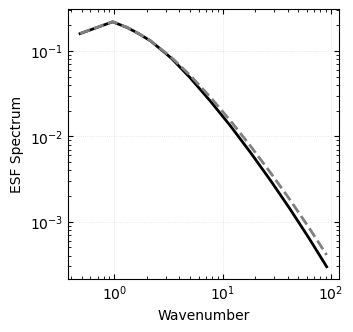

In [9]:
# Convert the lags that describe the grid indices into lags that represent the physical space
physical_lags = np.linalg.norm(lags, axis=1).reshape((N//2,)*D)*dx[0]
# Bin the SF
bins_sf, binned_sf, _ = binning.bin_data(
    physical_lags, sf2, bin_func=np.nanmean, min_bin=dx[0]-dx[0]/2, max_bin=geometry.DEFAULT_PHYS_SCALE/2., cut_excess=True, nan_small=False, ignore_nan=True, bin_loc='center')

# Compute the ESF spectrum
ke, biased_esf_spectrum, esf_spectrum = esf_integrated_spectrum(bins_sf, binned_sf, D, sf_subsample_num=16, powerlaw_subsample_num=8, fourier_wavenumbers=kp_integrated)
nyq = np.min([np.pi*N/geometry.DEFAULT_PHYS_SCALE, np.sqrt(2.)*N/geometry.DEFAULT_PHYS_SCALE - dk[0]])
esf_spectrum = esf_spectrum[ke<=nyq]
biased_esf_spectrum = biased_esf_spectrum[ke<=nyq]
ke = ke[ke<=nyq]

# Plot spectra
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(ke, esf_spectrum, linestyle='-', color='black', linewidth=2.)
ax.plot(ke, biased_esf_spectrum, linestyle='--', color='gray', linewidth=2.)
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('ESF Spectrum')
ax.set_xlabel('Wavenumber')

In [10]:
# Convert from the ESF integrated spectrum to the averaged spectrum
ke_averaged, feke_averaged = transform_spectrum(ke, esf_spectrum, D, 'integrated', 'averaged', grid_dims, bin_widths=p_widths[:len(ke)], is_centered=True)

Note that in this case, the biased spectrum is not too dissimilar to the debiased one.

### Difference-of-Gaussian (DoG)

The DoG method uses differences of Gaussian convolutions to estimate the power spectrum. This is done entirely in real-space. This method estimates the "angle-averaged" spectrum.

The DoG method supports GPU calculations for the Gaussian convolution (`kea.utils.set_calculation_mode(use_gpu=True)`).

Text(0.5, 0, 'Wavenumber')

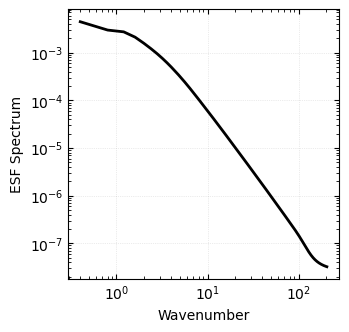

In [11]:
from kea.statistics.spectra import dog_averaged_spectrum
# Directly compute the DoG spectrum using Gaussian convolutions
kd, dog_spectrum = dog_averaged_spectrum(field)

# Plot spectra
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kd, dog_spectrum, linestyle='-', color='black', linewidth=2.)
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('ESF Spectrum')
ax.set_xlabel('Wavenumber')

### Comparison

Text(0.5, 0, 'Wavenumber')

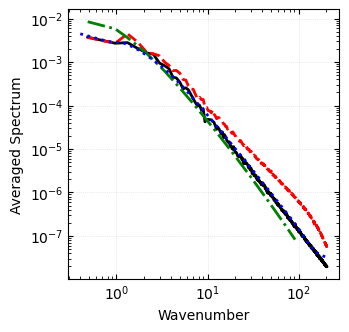

In [12]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kp_averaged, fek_averaged, linestyle='-', color='black', linewidth=2.)
ax.plot(kbt_averaged, fekbt_averaged, linestyle='--', color='red', linewidth=2.)
ax.plot(ke_averaged, feke_averaged, linestyle='-.', color='green', linewidth=2.)
ax.plot(kd, dog_spectrum, linestyle=':', color='blue', linewidth=2.)
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('Averaged Spectrum')
ax.set_xlabel('Wavenumber')
